In [3]:
import numpy as np
from mace.calculators import mace_mp, mace_off 
from pymatgen.core import Lattice, Structure
from pymatgen.transformations.standard_transformations import OrderDisorderedStructureTransformation

/Users/prakriti/anaconda3/envs/nep2/lib/python3.14/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


In [4]:
struct = Structure.from_file("/Users/prakriti/Downloads/MeOH_beta_2007.cif")
struct.add_oxidation_state_by_element({"C": -2, "O": -2, "H": +1})

trans = OrderDisorderedStructureTransformation()
ss = trans.apply_transformation(struct, return_ranked_list=1000)
print(len(ss))
print(ss[0])

/Users/prakriti/anaconda3/envs/nep2/lib/python3.14/site-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: Skipping relative stoichiometry check because CIF does not contain formula keys.
  struct = parser.parse_structures(primitive=primitive)[0]


1000
{'energy': np.float64(-400.76667089548914), 'energy_above_minimum': np.float64(0.0), 'structure': Structure Summary
Lattice
    abc : 6.401 7.22 4.647
 angles : 90.0 90.0 90.0
 volume : 214.76212733999998
      A : np.float64(6.401) np.float64(0.0) np.float64(3.919482080671104e-16)
      B : np.float64(-4.420974944921945e-16) np.float64(7.22) np.float64(4.420974944921945e-16)
      C : np.float64(0.0) np.float64(0.0) np.float64(4.647)
    pbc : True True True
PeriodicSite: H1 (H+) (0.224, 3.913, 4.02) [0.035, 0.542, 0.865]
PeriodicSite: H1 (H+) (0.224, 3.307, 1.696) [0.035, 0.458, 0.365]
PeriodicSite: H1 (H+) (2.976, 6.917, 1.696) [0.465, 0.958, 0.365]
PeriodicSite: H1 (H+) (2.976, 0.3032, 4.02) [0.465, 0.042, 0.865]
PeriodicSite: H2A (H+) (0.2752, 1.236, 3.188) [0.043, 0.1712, 0.686]
PeriodicSite: H2A (H+) (0.2752, 5.984, 0.8643) [0.043, 0.8288, 0.186]
PeriodicSite: H2A (H+) (2.925, 2.374, 0.8643) [0.457, 0.3288, 0.186]
PeriodicSite: H2A (H+) (2.925, 4.846, 3.188) [0.457, 0.6712,

In [5]:
import os
from pymatgen.io.cif import CifWriter
import matplotlib.pyplot as plt

output_dir = "/Users/prakriti/structures/methanol/ordered_structures"
os.makedirs(output_dir, exist_ok=True)

n = len(ss)
width = len(str(n))  # dynamic padding

for i, d in enumerate(ss):
    s = d["structure"]
    energy = d["energy"]
    filename = f"ordered_structure_{i:0{width}d}_energy_{energy:.4f}.cif"
    filepath = os.path.join(output_dir, filename)
    writer = CifWriter(s)
    writer.write_file(filepath)     



/var/folders/88/zggs9nvj5v5f_7kv6xp6y01w0000gn/T/ipykernel_63195/3823938717.py:16: UserWarning: Site labels are not unique, which is not compliant with the CIF spec (https://www.iucr.org/__data/iucr/cifdic_html/1/cif_core.dic/Iatom_site_label.html):`['H1', 'H1', 'H1', 'H1', 'H2A', 'H2A', 'H2A', 'H2A', 'H2B', 'H2B', 'H2B', 'H2B', 'H2B', 'H2B', 'H2B', 'H2B', 'C2', 'C2', 'C2', 'C2', 'O1', 'O1', 'O1', 'O1']`.
  writer = CifWriter(s)
/var/folders/88/zggs9nvj5v5f_7kv6xp6y01w0000gn/T/ipykernel_63195/3823938717.py:16: UserWarning: Site labels are not unique, which is not compliant with the CIF spec (https://www.iucr.org/__data/iucr/cifdic_html/1/cif_core.dic/Iatom_site_label.html):`['H1', 'H1', 'H1', 'H1', 'H2A', 'H2A', 'H2A', 'H2A', 'H2B', 'H2B', 'H2B', 'H2B', 'H2B', 'H2B', 'H2B', 'H2C', 'C2', 'C2', 'C2', 'C2', 'O1', 'O1', 'O1', 'O1']`.
  writer = CifWriter(s)
/var/folders/88/zggs9nvj5v5f_7kv6xp6y01w0000gn/T/ipykernel_63195/3823938717.py:16: UserWarning: Site labels are not unique, which is n

In [6]:
from pymatgen.io.ase import AseAtomsAdaptor

# Load the MACE-MP-0b3 foundational model
calc = mace_mp(model="medium", dispersion=False, default_dtype="float32")

mace_mp_energies = []

for d in ss:
    s = d["structure"]
    atoms = AseAtomsAdaptor.get_atoms(s)
    atoms.calc = calc
    energy = atoms.get_potential_energy()
    mace_mp_energies.append(energy)

print("MACE energies calculated for", len(mace_mp_energies), "structures")

calc = mace_off(model="medium", dispersion=False, default_dtype="float32")

mace_off_energies = []

for d in ss:
    s = d["structure"]
    atoms = AseAtomsAdaptor.get_atoms(s)
    atoms.calc = calc
    energy = atoms.get_potential_energy()
    mace_off_energies.append(energy)

print("MACE energies calculated for", len(mace_off_energies), "structures")

/Users/prakriti/anaconda3/envs/nep2/lib/python3.14/site-packages/mace/calculators/mace.py:199: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Using Materials Project MACE for MACECalculator with /Users/prakriti/.cache/mace/20231203mace128L1_epoch199model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.


/Users/prakriti/anaconda3/envs/nep2/lib/python3.14/site-packages/mace/calculators/mace.py:199: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


MACE energies calculated for 1000 structures
Using MACE-OFF23 MODEL for MACECalculator with /Users/prakriti/.cache/mace/MACE-OFF23_medium.model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.
MACE energies calculated for 1000 structures


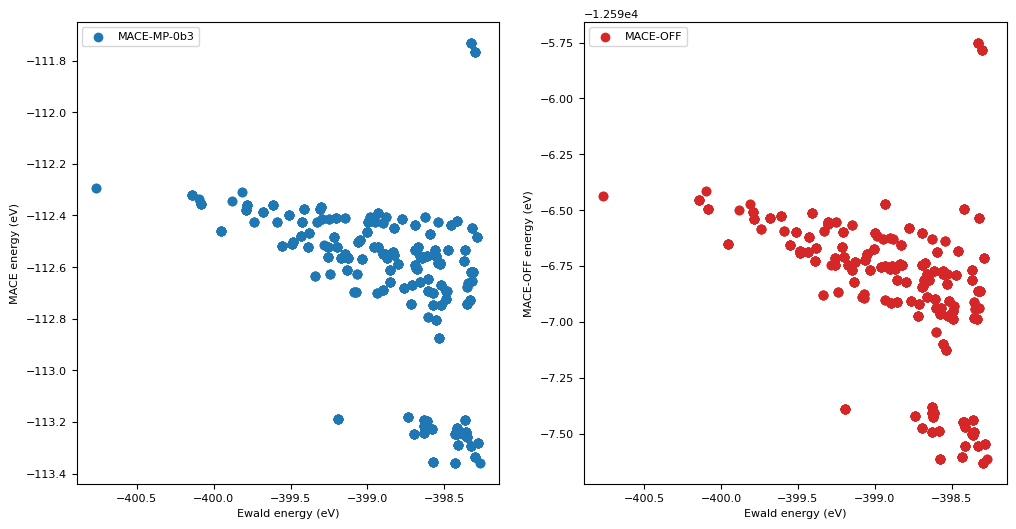

In [7]:

ewald_energies = [d['energy'] for d in ss]  

fig,(ax1,ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.scatter(ewald_energies, mace_mp_energies, color='tab:blue', label='MACE-MP-0b3')
ax2.scatter(ewald_energies, mace_off_energies, color='tab:red', label='MACE-OFF')
ax1.set_xlabel('Ewald energy (eV)')
ax2.set_xlabel('Ewald energy (eV)')
ax1.set_ylabel('MACE energy (eV)')
ax2.set_ylabel('MACE-OFF energy (eV)')
ax1.legend()
ax2.legend()
plt.savefig('energies_comparison.png')
plt.show()

In [8]:
mace_off_energies,ewald_energies

([-12596.4345703125,
  -12596.4345703125,
  -12596.4560546875,
  -12596.4560546875,
  -12596.4560546875,
  -12596.4560546875,
  -12596.4560546875,
  -12596.4560546875,
  -12596.4560546875,
  -12596.4560546875,
  -12596.416015625,
  -12596.416015625,
  -12596.4951171875,
  -12596.4951171875,
  -12596.4951171875,
  -12596.4951171875,
  -12596.4951171875,
  -12596.4951171875,
  -12596.4951171875,
  -12596.4951171875,
  -12596.65234375,
  -12596.65234375,
  -12596.65234375,
  -12596.65234375,
  -12596.65234375,
  -12596.65234375,
  -12596.65234375,
  -12596.65234375,
  -12596.498046875,
  -12596.498046875,
  -12596.474609375,
  -12596.474609375,
  -12596.5068359375,
  -12596.5068359375,
  -12596.5068359375,
  -12596.5068359375,
  -12596.5068359375,
  -12596.5068359375,
  -12596.5068359375,
  -12596.5068359375,
  -12596.5400390625,
  -12596.5400390625,
  -12596.5400390625,
  -12596.5400390625,
  -12596.5400390625,
  -12596.5400390625,
  -12596.5400390625,
  -12596.5400390625,
  -12596.58593

(np.float64(-113.43926162719727),
 np.float64(-111.64936141967773),
 np.float64(-12597.723828125),
 np.float64(-12595.65703125))

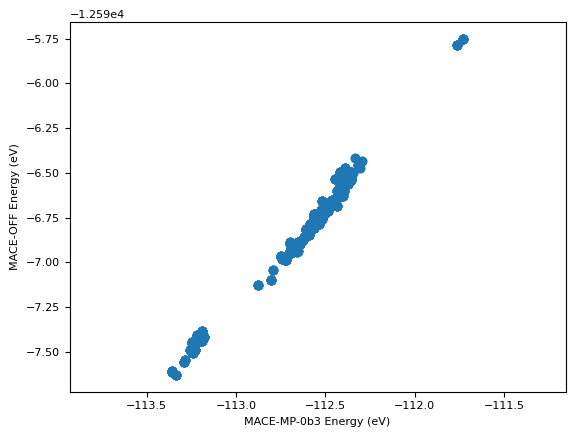

In [12]:
plt.scatter(mace_mp_energies,mace_off_energies, label='MACE-MP-0b3')
plt.xlabel('MACE-MP-0b3 Energy (eV)')
plt.ylabel('MACE-OFF Energy (eV)')
plt.axis('equal')